# Preprocessing Sensitivity Analysis

**Date:** September 22, 2026

**Purpose:** Fulfill the commitment made in Section II of the paper
to examine whether CV PR-AUC results are sensitive to preprocessing
threshold choices.

**Reviewer concern addressed:** "The authors' findings may be an
artifact of their specific preprocessing choices (50% missingness
threshold, zero-variance removal) rather than reflecting genuine model performance."

**Experimental design:**
Repeat full preprocessing and 5-fold CV under three conditions:

- Conservative: 30% missingness threshold
- Baseline: 50% missingness threshold (reported results)
- Permissive: 70% missingness threshold

Primary model: XGBoost (200 trees) — best CV PR-AUC in primary analysis.

Metric: CV PR-AUC mean ± std across 5 folds.

Robust finding: results stable (within ±0.010) across all three thresholds.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

FIGURES = Path('../reports/figures')

X_raw = pd.read_csv(
    Path('../data/raw/secom.data'),
    sep=r'\s+', header=None, engine='python'
)
y_raw = pd.read_csv(
    Path('../data/raw/secom_labels.data'),
    sep=r'\s+', header=None, names=['label','timestamp']
)
y = (y_raw['label'] == 1).astype(int)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
thresholds_to_test = [0.30, 0.50, 0.70]
sensitivity_results = []

for threshold in thresholds_to_test:
    # Preprocessing
    variances = X_raw.var()
    X_s1 = X_raw.loc[:, variances > 0]
    missing_rate = X_s1.isnull().mean()
    X_s2 = X_s1.loc[:, missing_rate <= threshold]
    
    imputer = SimpleImputer(strategy='median')
    X_imputed = pd.DataFrame(
        imputer.fit_transform(X_s2),
        columns=X_s2.columns.astype(str)
    )
    
    n_features = X_imputed.shape[1]
    neg = (y == 0).sum()
    pos = (y == 1).sum()
    
    # Manual CV loop
    fold_scores = []
    for train_idx, test_idx in cv5.split(X_imputed, y):
        X_tr = X_imputed.iloc[train_idx]
        X_te = X_imputed.iloc[test_idx]
        y_tr = y.iloc[train_idx]
        y_te = y.iloc[test_idx]
        
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', xgb.XGBClassifier(
                n_estimators=200, max_depth=4,
                learning_rate=0.05, subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=neg/pos,
                reg_alpha=0.1, reg_lambda=1.0,
                random_state=42, n_jobs=-1, verbosity=0
            ))
        ])
        pipeline.fit(X_tr, y_tr)
        y_prob = pipeline.predict_proba(X_te)[:, 1]
        fold_scores.append(average_precision_score(y_te, y_prob))
    
    result = {
        'Threshold': f'{int(threshold*100)}%',
        'Features Retained': n_features,
        'CV PR-AUC Mean': round(np.mean(fold_scores), 4),
        'CV PR-AUC Std': round(np.std(fold_scores), 4)
    }
    sensitivity_results.append(result)
    print(f"Threshold {int(threshold*100)}%: "
          f"{n_features} features | "
          f"PR-AUC = {result['CV PR-AUC Mean']:.4f} "
          f"± {result['CV PR-AUC Std']:.4f}")

sens_df = pd.DataFrame(sensitivity_results)
print(f"\n{'='*60}")
print(sens_df.to_string(index=False))

pr_range = sens_df['CV PR-AUC Mean'].max() - sens_df['CV PR-AUC Mean'].min()
print(f"\nPR-AUC range across thresholds: {pr_range:.4f}")
if pr_range <= 0.010:
    print("ROBUST: Results stable across preprocessing choices.")
elif pr_range <= 0.025:
    print("MODERATELY ROBUST: Small sensitivity to threshold choice.")
else:
    print("SENSITIVE: Results depend meaningfully on preprocessing.")

sens_df.to_csv(Path('../data/processed/sensitivity_analysis.csv'), index=False)

Threshold 30%: 442 features | PR-AUC = 0.1797 ± 0.0241
Threshold 50%: 446 features | PR-AUC = 0.1910 ± 0.0271
Threshold 70%: 466 features | PR-AUC = 0.1916 ± 0.0342

Threshold  Features Retained  CV PR-AUC Mean  CV PR-AUC Std
      30%                442          0.1797         0.0241
      50%                446          0.1910         0.0271
      70%                466          0.1916         0.0342

PR-AUC range across thresholds: 0.0119
MODERATELY ROBUST: Small sensitivity to threshold choice.


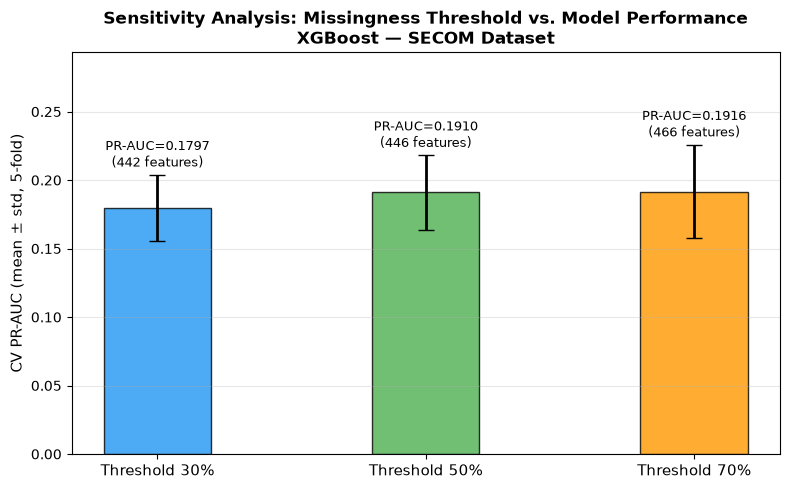

Figure saved.


In [3]:
fig, ax = plt.subplots(figsize=(8, 5))

means = sens_df['CV PR-AUC Mean'].values
stds  = sens_df['CV PR-AUC Std'].values
labels = sens_df['Threshold'].values
x = np.arange(len(labels))

bars = ax.bar(x, means, yerr=stds, capsize=6,
              color=['#2196F3','#4CAF50','#FF9800'],
              edgecolor='black', alpha=0.8, width=0.4,
              error_kw={'linewidth': 2})

for bar, mean, feat in zip(bars, means, sens_df['Features Retained']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + stds[list(means).index(mean)] + 0.003,
            f'PR-AUC={mean:.4f}\n({feat} features)',
            ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f'Threshold {t}' for t in labels], fontsize=11)
ax.set_ylabel('CV PR-AUC (mean ± std, 5-fold)', fontsize=11)
ax.set_title('Sensitivity Analysis: Missingness Threshold vs. Model Performance\n'
             'XGBoost — SECOM Dataset', fontsize=12, fontweight='bold')
ax.set_ylim([0, max(means + stds) * 1.3])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / 'sensitivity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")